In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score


In [ ]:
iris = load_iris()
X, y = iris.data, iris.target


In [ ]:
def k_fold_cv(X, y, k=5, n_neighbors=5):
    fold_size = len(X) // k
    accuracies = []

    for i in range(k):
        start, end = i * fold_size, (i + 1) * fold_size

        X_test, y_test = X[start:end], y[start:end]
        X_train = np.vstack([X[:start], X[end:]])
        y_train = np.hstack([y[:start], y[end:]])

        knn = KNeighborsClassifier(n_neighbors=n_neighbors)
        knn.fit(X_train, y_train)
        y_pred = knn.predict(X_test)

        accuracies.append(accuracy_score(y_test, y_pred))

    return accuracies, np.mean(accuracies)



In [ ]:
accuracies, avg_accuracy = k_fold_cv(X, y, k=10)

print("\nFold-wise Accuracy:")
for i, acc in enumerate(accuracies, start=1):
    print(f"Fold {i} Accuracy = {acc:.4f}")

print(f"\nAverage k-NN accuracy (k-Fold CV): {avg_accuracy:.3f}")



Fold-wise Accuracy:
Fold 1 Accuracy = 1.0000
Fold 2 Accuracy = 1.0000
Fold 3 Accuracy = 1.0000
Fold 4 Accuracy = 1.0000
Fold 5 Accuracy = 0.8000
Fold 6 Accuracy = 0.8667
Fold 7 Accuracy = 1.0000
Fold 8 Accuracy = 0.8667
Fold 9 Accuracy = 0.8000
Fold 10 Accuracy = 1.0000

Average k-NN accuracy (k-Fold CV): 0.933


In [ ]:
def bootstrap_regression(X, y, n_bootstraps=1000):
    n_samples = len(X)
    coefs = []

    for _ in range(n_bootstraps):
        indices = np.random.choice(n_samples, n_samples, replace=True)
        X_boot = X[indices]
        y_boot = y[indices]

        model = LinearRegression()
        model.fit(X_boot, y_boot)
        coefs.append(model.coef_)

    return np.array(coefs)


In [ ]:
X_reg = X[:, :2]      # First two features
y_reg = X[:, 2]       # Third feature


In [ ]:
coefs = bootstrap_regression(X_reg, y_reg, n_bootstraps=500)


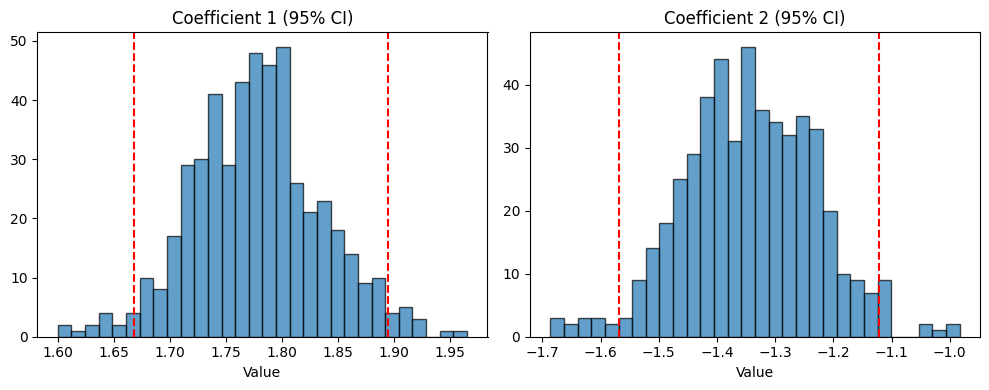

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(coefs[:, 0], bins=30, alpha=0.7, edgecolor='black')
plt.axvline(np.percentile(coefs[:, 0], 2.5), color='red', linestyle='--')
plt.axvline(np.percentile(coefs[:, 0], 97.5), color='red', linestyle='--')
plt.title('Coefficient 1 (95% CI)')
plt.xlabel('Value')

plt.subplot(1, 2, 2)
plt.hist(coefs[:, 1], bins=30, alpha=0.7, edgecolor='black')
plt.axvline(np.percentile(coefs[:, 1], 2.5), color='red', linestyle='--')
plt.axvline(np.percentile(coefs[:, 1], 97.5), color='red', linestyle='--')
plt.title('Coefficient 2 (95% CI)')
plt.xlabel('Value')

plt.tight_layout()
plt.show()


In [ ]:
print("\nBootstrap results (95% confidence intervals):")
for i in range(coefs.shape[1]):
    lower = np.percentile(coefs[:, i], 2.5)
    upper = np.percentile(coefs[:, i], 97.5)
    print(f"Coefficient {i+1}: [{lower:.3f}, {upper:.3f}]")



Bootstrap results (95% confidence intervals):
Coefficient 1: [1.668, 1.895]
Coefficient 2: [-1.569, -1.121]


In [ ]:
from sklearn.model_selection import KFold
import numpy as np

# Create example data
data = np.arange(100)
X = data              # Features
y = data * 2          # Target

# Create KFold object
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Split data
folds = []
for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    folds.append((X_train, X_test, y_train, y_test))
    print(f"Train: {len(train_index)}, Test: {len(test_index)}")


Train: 80, Test: 20
Train: 80, Test: 20
Train: 80, Test: 20
Train: 80, Test: 20
Train: 80, Test: 20
